# HOMEWORK 7

In this homework you are going to rectify a document image that suffers from severe distortion. You will be using the same image and the same detected corners from the previous lesson (lesson 6).

Remember, OpenCV documentation is your friend ;-)

At the end of this notebook, there are a couple of questions for you to answer.

In [10]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image we will be working on in this homework.

(<Axes: >, <matplotlib.image.AxesImage at 0x1e71aff9dd0>)

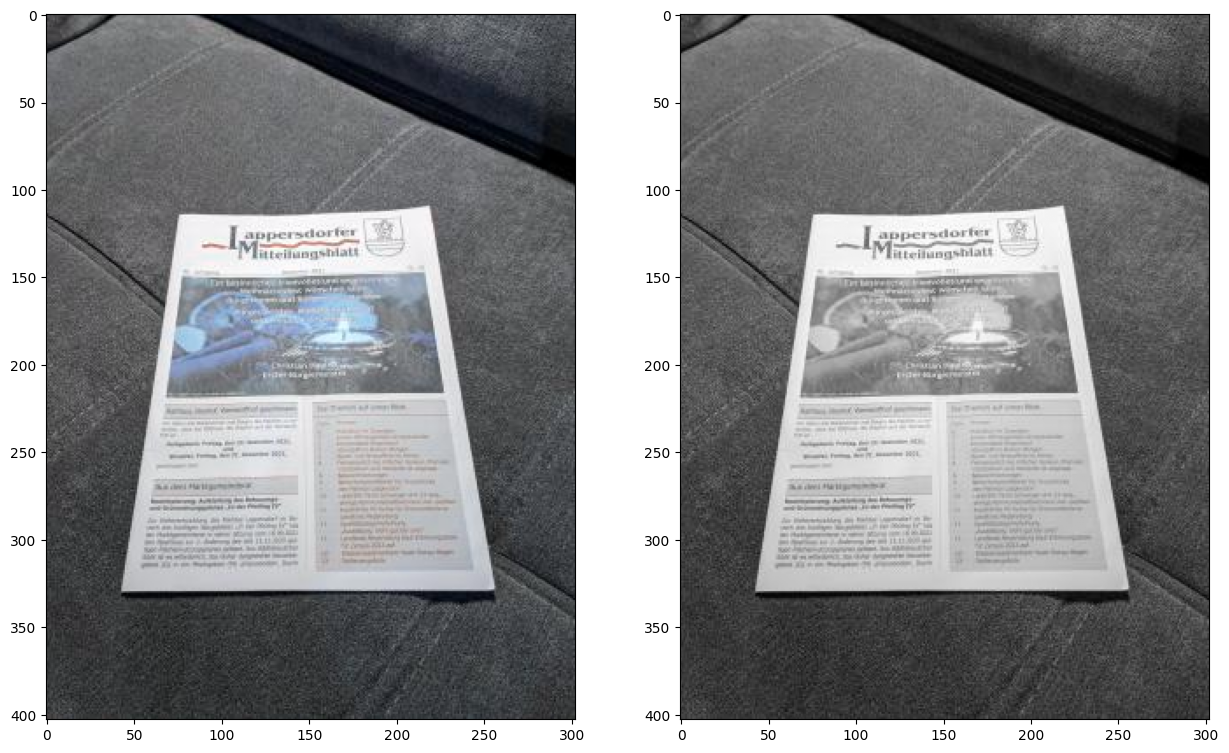

In [11]:
img = cv2.imread('data/document.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray) / 255
rows, cols = gray.shape

# Let's plot the image
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(gray, cmap='gray')

In the previous homework you should have detected the four document corners and you will need to use them here. But don't worry if the previous homework did not work out for you, I am going to provide you with the corners coordinates here :-)

In [12]:
top_left = [76, 115]
top_right = [219, 111]
bottom_left = [43, 330]
bottom_right = [256, 329]

(<Axes: >, <matplotlib.image.AxesImage at 0x1e716b82210>)

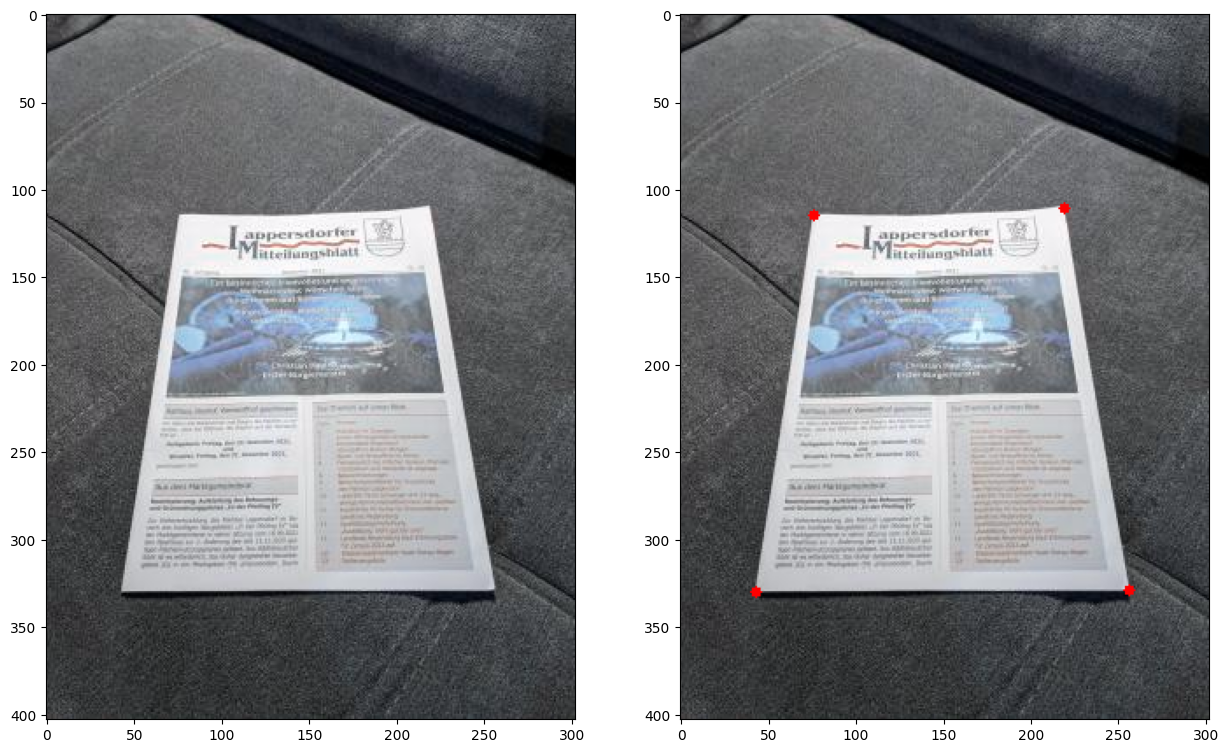

In [13]:
# Let's plot the points
out = np.copy(img)
out = cv2.circle(out, tuple(top_left), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(top_right), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(bottom_left), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(bottom_right), 3, (255,0,0), -1)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(out)

### Document Rectification

Let's now try to rectify the document. The goal is to bring the four document corners to the image corners. For instance, we want the top-left document corner to become (0, 0), i.e., the top-left corner of the image itself. In that way, we will fill the complete image with document information and we will throw away parts of the images that correspond to background (which are of no use to us).

In [14]:
# Исходные точки - углы документа на изображении
src = np.array([top_left, top_right, bottom_left, bottom_right], dtype=np.float32)

# Целевые точки - углы самого изображения (куда хотим переместить углы документа)
dst = np.array([[0, 0], [cols-1, 0], [0, rows-1], [cols-1, rows-1]], dtype=np.float32)

Let's first start with the affine transform for document rectification. The affine transform can be analytically calculated using 3 point pairs. Therefore, let's select the **first 3 points** and calculate the corresponding transform. We will then use the transform to rectify the document.

(<Axes: >, <matplotlib.image.AxesImage at 0x1e716c60a50>)

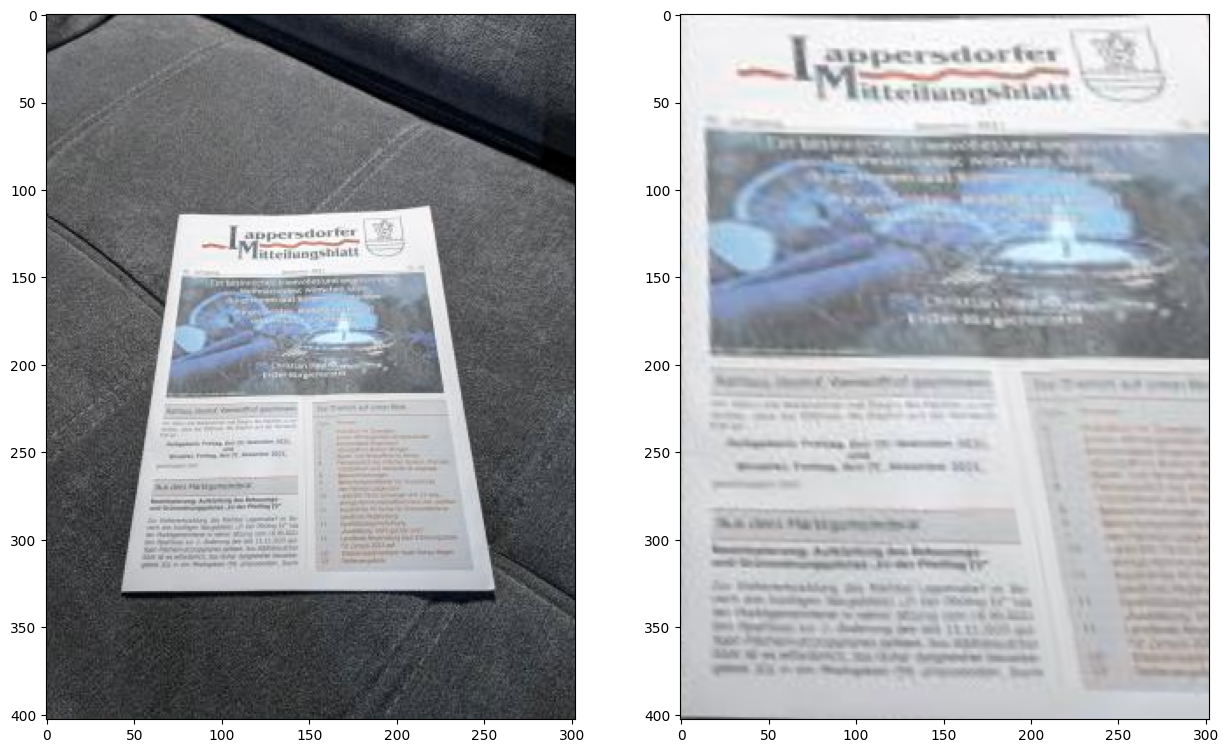

In [15]:
# Вычисляем аффинное преобразование по первым 3 точкам
M = cv2.getAffineTransform(src[:3], dst[:3])

# Применяем преобразование к изображению
rectified = cv2.warpAffine(img, M, (cols, rows))

# Смотрим результат
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

Well, this is not bad but certainly not what we were aiming for. Let's try the **last 3** points instead.

(<Axes: >, <matplotlib.image.AxesImage at 0x1e719bf1dd0>)

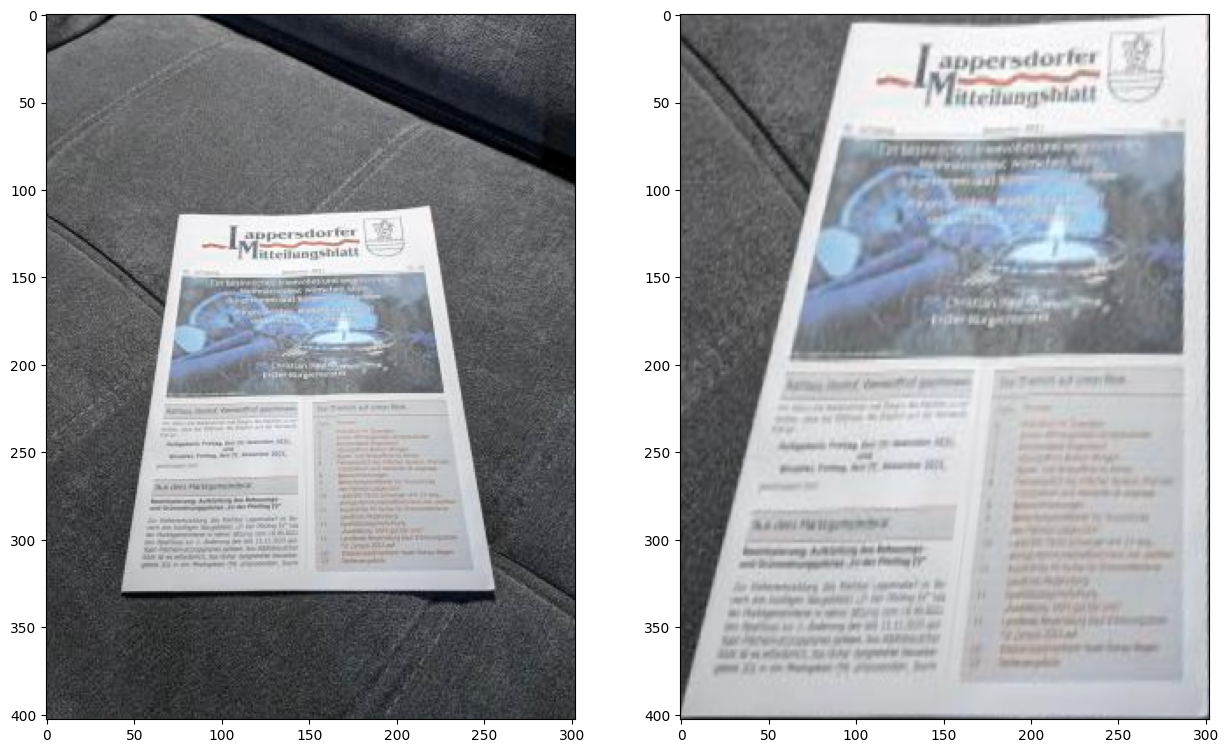

In [16]:
# Вычисляем аффинное преобразование по последним 3 точкам
M = cv2.getAffineTransform(src[1:], dst[1:])

# Применяем преобразование
rectified = cv2.warpAffine(img, M, (cols, rows))

# Смотрим результат
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

The result looks different but not better. This approach doesn't seem to be helping then. Let's use **all 4 points** and let OpenCV **estimate** (remember that 4 points are too many for an analytical solution) the best fitting affine transform for us. It'll internally apply optimization approaches as well as RANSAC.

(<Axes: >, <matplotlib.image.AxesImage at 0x1e71b51c9d0>)

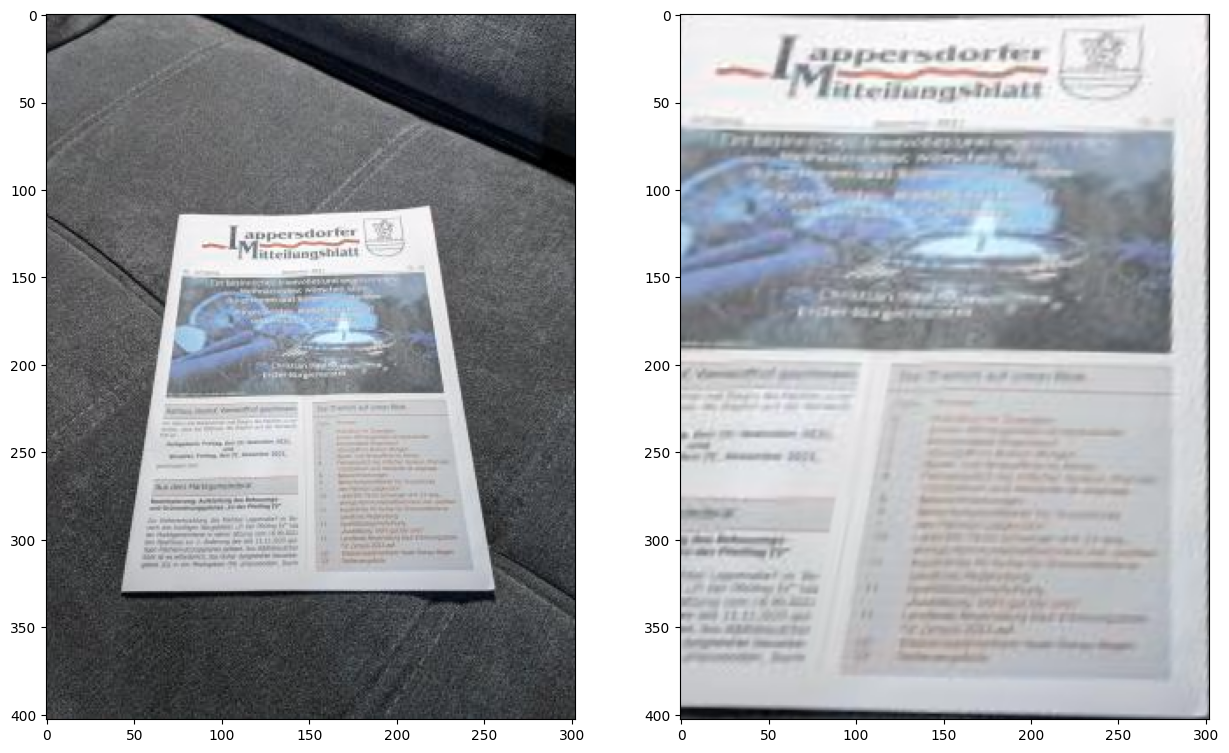

In [17]:
# Оцениваем оптимальное аффинное преобразование по всем 4 точкам
M, inliers = cv2.estimateAffine2D(src, dst)

# Применяем преобразование
rectified = cv2.warpAffine(img, M, (cols, rows))

# Смотрим результат
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

There is not much of an improvement either. Let's try homography instead of affine transform. Remember that for computing the homography analytically we need to use 4 pairs of points.

(<Axes: >, <matplotlib.image.AxesImage at 0x1e71b989e50>)

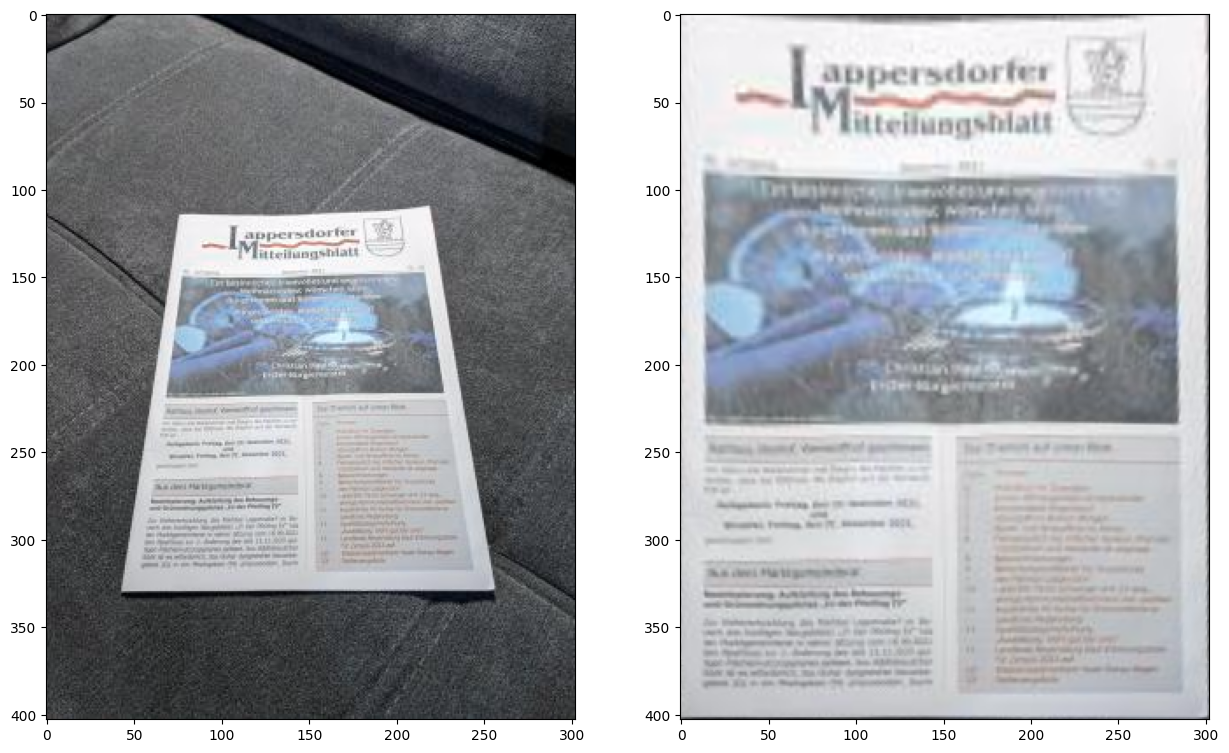

In [18]:
# Вычисляем матрицу гомографии по 4 точкам
M = cv2.getPerspectiveTransform(src, dst)

# Применяем перспективное преобразование
rectified = cv2.warpPerspective(img, M, (cols, rows))

# Смотрим результат
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

### Ответы

**1. Почему аффинное преобразование плохо работает?**

Аффинное преобразование не может исправить перспективные искажения, потому что оно сохраняет параллельность линий. На нашем фото документ снят под углом, и его стороны сходятся, а аффинное преобразование такое не моделирует. Также оно определяется по 3 точкам, а у нас 4 угла. При любом выборе тройки четвёртая точка не попадает куда нужно.

**2. Что с вектором inliers?**

Все 4 значения равны 1, то есть все точки считаются инлайерами. Это логично, потому что точки заданы вручную и корректно, аутлайеров нет. Но это не говорит о том, что аффинная модель подходит для задачи. Точки правильные, а модель нет.

**3. Как выглядит результат гомографии?**

Документ выровнен, все 4 угла совпали с углами изображения. Гомография справляется с перспективой, потому что использует все 4 точки. Но при этом пропорции документа изменились. Исходный документ вытянут вертикально, а результат растянут на всё изображение, которое имеет другое соотношение сторон. То есть текст на документе может выглядеть сжатым или растянутым по одной из осей. 
